In [26]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import itertools
from scipy import stats
import matplotlib.cm as cm
import matplotlib.dates as mdates
import seaborn as sns

In [27]:
df_cancelled = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv", sep=';')
df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')

/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_62693/3600004165.py:2: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')


In [45]:
df_complete.head()
df_complete.columns
df_complete.info()
df_complete.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133158 entries, 0 to 133157
Columns: 247 entries, Case-ID Anonymous to Ressource.Kasette
dtypes: float64(216), int64(3), object(28)
memory usage: 250.9+ MB


,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Dato,Pt ankommet til hospitalet,Planlagt stue klargøring start,Stue klargøring start,...,Ressource.Olympus Exera II (anæstesisøjle),Ressource.Sonostar,Ressource.COP3589 A O bøjejern rekonstruktionsskinner,Ressource.BMAC-centrifuge,Ressource.Benchbord,Ressource.Diodelaser næse,Ressource.Øre optik 30°,Ressource.Endoskop,Ressource.Flexcystoskop,Ressource.Kasette
count,133158.000000,133158.000000,133158,133038,133158.000000,133158,133158,132661,132735,119950,...,2.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,2.0,0.0
unique,NaN,NaN,32,128,NaN,2,731,89230,54949,82602,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Øjenkirurgi,GLO Ø 46 STUE 08,NaN,Nej,"2025-04-30 00:00:00,000","2025-06-12 19:15:00,000","2025-01-13 08:00:00,000","2024-06-10 07:45:00,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,40868,3424,NaN,106513,336,51,93,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,60156.037437,53.788244,NaN,NaN,40663.550909,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
std,34927.061620,24.889920,NaN,NaN,52262.972747,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN
min,1.000000,0.000000,NaN,NaN,618.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
25%,29928.250000,34.000000,NaN,NaN,622.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
50%,60097.500000,61.000000,NaN,NaN,625.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
75%,90338.750000,74.000000,NaN,NaN,107621.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


In [50]:
staff_cols = [c for c in df_complete.columns if c.startswith("Staff.")]
resource_cols = [c for c in df_complete.columns if c.startswith("Ressource.")]

In [52]:
df_complete["staff_count"] = df_complete[staff_cols].notna().sum(axis=1)
df_complete["resource_count"] = df_complete[resource_cols].notna().sum(axis=1)

In [54]:
df_complete[["staff_count","resource_count","Forsinkelse (minutter)"]].corr()

,staff_count,resource_count,Forsinkelse (minutter)
staff_count,1.000000,0.471781,-0.128937
resource_count,0.471781,1.000000,-0.119953
Forsinkelse (minutter),-0.128937,-0.119953,1.000000


In [28]:
df_complete_wo = df_complete.drop(columns=[col for col in df_complete.columns if col.startswith("Ressource")])
df_complete_wo = df_complete_wo.drop(columns=[col for col in df_complete_wo.columns if col.startswith("Staff")])
df_complete_wo.columns, df_complete_wo.shape[1]

(Index(['Case-ID Anonymous', 'Patient Alder', 'Speciale', 'Stue',
        'Operationsgang ID', 'Akut case (J/N)', 'Dato',
        'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
        'Stue klargøring start', 'Stue klargjort',
        'Patient på stuen (Planlagt)', 'Patient på stuen', 'Anæstesistart',
        'Anæstesi melder klar', 'Procedure start', 'Procedure slut',
        'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
        'Patient forlader stuen', 'Stue rengjort (Planlagt)',
        'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop',
        'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling',
        'Forsinkelse (minutter)', 'Overskredet (minutter)', 'Forsinkelsesårsag',
        'Procedure - Tekst & ID', 'Aktionsdiagnose - Kode & tekst',
        'Aktionsdiagnose - Gruppe'],
       dtype='object'),
 33)

In [29]:
# Make datetime objects
df_complete_wo['Dato'] = pd.to_datetime(df_complete_wo['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Pt ankommet til hospitalet'] = pd.to_datetime(df_complete_wo['Pt ankommet til hospitalet'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Planlagt stue klargøring start'] = pd.to_datetime(df_complete_wo['Planlagt stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargøring start'] = pd.to_datetime(df_complete_wo['Stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargjort'] = pd.to_datetime(df_complete_wo['Stue klargjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen'] = pd.to_datetime(df_complete_wo['Patient på stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient på stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistart'] = pd.to_datetime(df_complete_wo['Anæstesistart'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesi melder klar'] = pd.to_datetime(df_complete_wo['Anæstesi melder klar'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure start'] = pd.to_datetime(df_complete_wo['Procedure start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure slut'] = pd.to_datetime(df_complete_wo['Procedure slut'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient klar til afgang'] = pd.to_datetime(df_complete_wo['Patient klar til afgang'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient forlader stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen'] = pd.to_datetime(df_complete_wo['Patient forlader stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort (Planlagt)'] = pd.to_datetime(df_complete_wo['Stue rengjort (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengøring start'] = pd.to_datetime(df_complete_wo['Stue rengøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort'] = pd.to_datetime(df_complete_wo['Stue rengjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['I opvågning'] = pd.to_datetime(df_complete_wo['I opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistop'] = pd.to_datetime(df_complete_wo['Anæstesistop'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Klar til udskrivelse efter opvågning'] = pd.to_datetime(df_complete_wo['Klar til udskrivelse efter opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader afdeling'] = pd.to_datetime(df_complete_wo['Patient forlader afdeling'], format='%Y-%m-%d %H:%M:%S,%f')

In [60]:
df_complete_wo["prep_time"] = (df_complete_wo["Procedure start"] - df_complete_wo["Patient på stuen"]
).dt.total_seconds() / 60

df_complete_wo["surgery_time"] = (
    df_complete_wo["Procedure slut"] - df_complete_wo["Procedure start"]
).dt.total_seconds() / 60

df_complete_wo["recovery_room_time"] = (
    df_complete_wo["Patient forlader stuen"] - df_complete_wo["Procedure slut"]
).dt.total_seconds() / 60

df_complete_wo["cleaning_time"] = (
    df_complete_wo["Stue rengjort"] - df_complete_wo["Stue rengøring start"]
).dt.total_seconds() / 60

In [62]:
df_complete_wo.loc[df_complete_wo["prep_time"] < 0, "prep_time"] = np.nan
df_complete_wo.loc[df_complete_wo["surgery_time"] < 0, "surgery_time"] = np.nan
df_complete_wo.loc[df_complete_wo["recovery_room_time"] < 0, "recovery_room_time"] = np.nan
df_complete_wo.loc[df_complete_wo["cleaning_time"] < 0, "cleaning_time"] = np.nan

In [63]:
df_complete_wo[["prep_time", "surgery_time", "recovery_room_time", "cleaning_time"]].describe()

,prep_time,surgery_time,recovery_room_time,cleaning_time
count,132214.000000,132264.000000,132213.000000,54004.000000
mean,33.491499,66.716514,17.159765,3.335642
std,27.673674,76.531662,18.433585,14.071365
min,0.000000,0.000000,0.000000,0.000000
25%,10.000000,18.000000,5.000000,0.000000
50%,29.000000,40.000000,15.000000,0.000000
75%,48.000000,85.000000,24.000000,0.000000
max,1572.000000,1845.000000,1470.000000,1474.000000


In [30]:
df_complete_wo['Dato']

0        2024-03-07
1        2024-01-05
2        2024-01-05
3        2024-01-26
4        2024-10-01
            ...    
133153   2025-12-18
133154   2025-12-23
133155   2025-12-19
133156   2025-12-22
133157   2025-12-19
Name: Dato, Length: 133158, dtype: datetime64[ns]

In [31]:
df_complete_wo['Speciale'].nunique(), df_complete_wo['Speciale'].unique(), df_complete_wo['Speciale'].value_counts()

(32,
 array(['Øre-næse-hals', 'Plastikkirurgi', 'Tand- mund- og kæbekirurgi',
        'Øjenkirurgi', 'Børnekirurgi', 'Ortopædkirurgi', 'Børneortopædi',
        'Karkirurgi', 'Thoraxkirurgi', 'Hjertekirurgi', 'Urologi',
        'Håndkirurgi', 'Kirurgi', 'Neurokirurgi', 'Pædiatri', 'Obstetrik',
        'Gynækologi', 'Gynækologi-obstetrik', 'Lungesygdomme',
        'Alloplastik', 'Traumeortopædi', 'Tumorortopædi', 'Rygkirurgi',
        'Neurologi', 'Hæmatologi-Onkologi pædiatrisk', 'Onkologi',
        'Medicinsk gastroenterologi', 'Hæmatologi', 'Kardiologi',
        'Nefrologi', 'Anæstesiologi', 'Brystkirurgi'], dtype=object),
 Speciale
 Øjenkirurgi                       40868
 Øre-næse-hals                     14010
 Plastikkirurgi                     9077
 Rygkirurgi                         7346
 Neurokirurgi                       6842
 Tand- mund- og kæbekirurgi         6125
 Karkirurgi                         5662
 Thoraxkirurgi                      5258
 Kirurgi                      

In [32]:
# 2. Opret en kolonne med kun året
df_complete_wo['År'] = df_complete_wo['Dato'].dt.year

# 3. Gruppér data for at tælle antal operationer pr. speciale pr. år
plot_data = df_complete_wo.groupby(['År', 'Speciale']).size().reset_index(name='Antal')

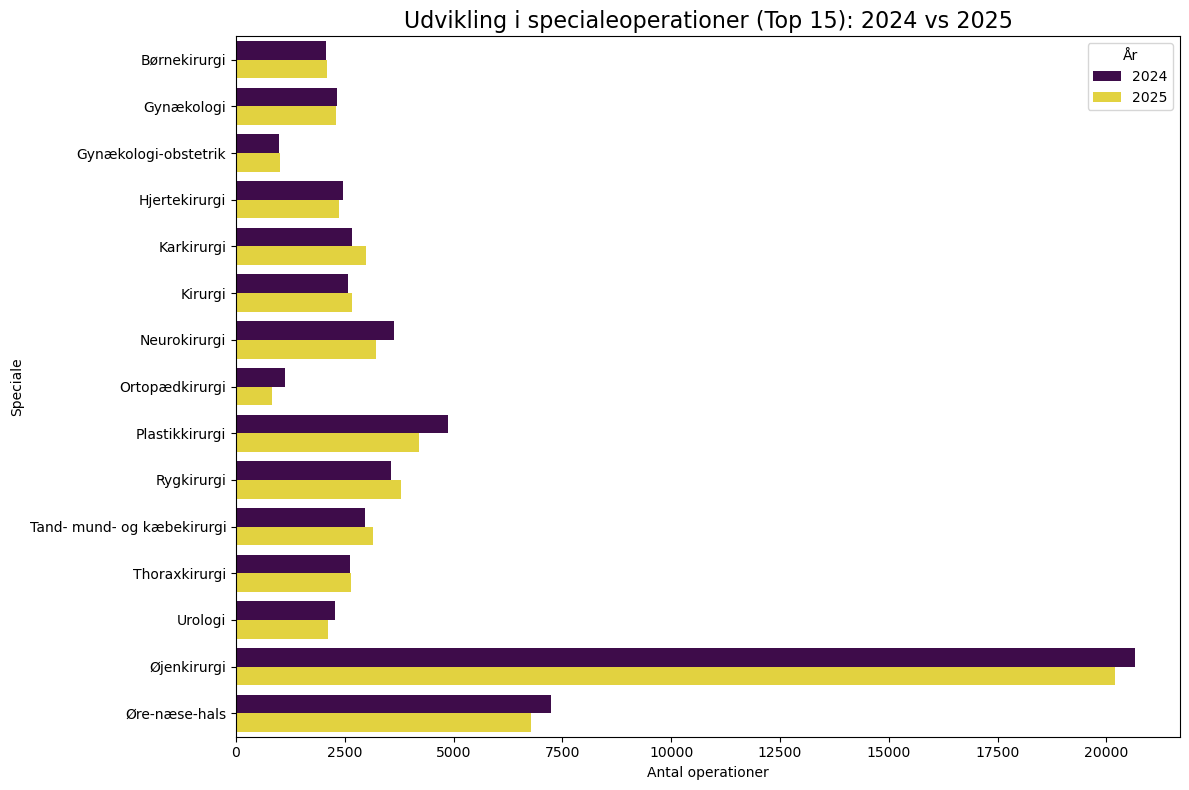

In [33]:
# Vi tager de 15 største specialer for at holde det overskueligt
top_specialer = df_complete_wo['Speciale'].value_counts().nlargest(15).index
filtered_data = plot_data[plot_data['Speciale'].isin(top_specialer)]

plt.figure(figsize=(12, 8))
sns.barplot(data=filtered_data, x='Antal', y='Speciale', hue='År', palette='viridis')

plt.title('Udvikling i specialeoperationer (Top 15): 2024 vs 2025', fontsize=16)
plt.xlabel('Antal operationer')
plt.ylabel('Speciale')
plt.legend(title='År')
plt.tight_layout()
plt.show()

/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_62693/1733871559.py:8: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_pivot = df_indexed.groupby('Speciale').resample('ME').size().unstack(level=0).fillna(0)


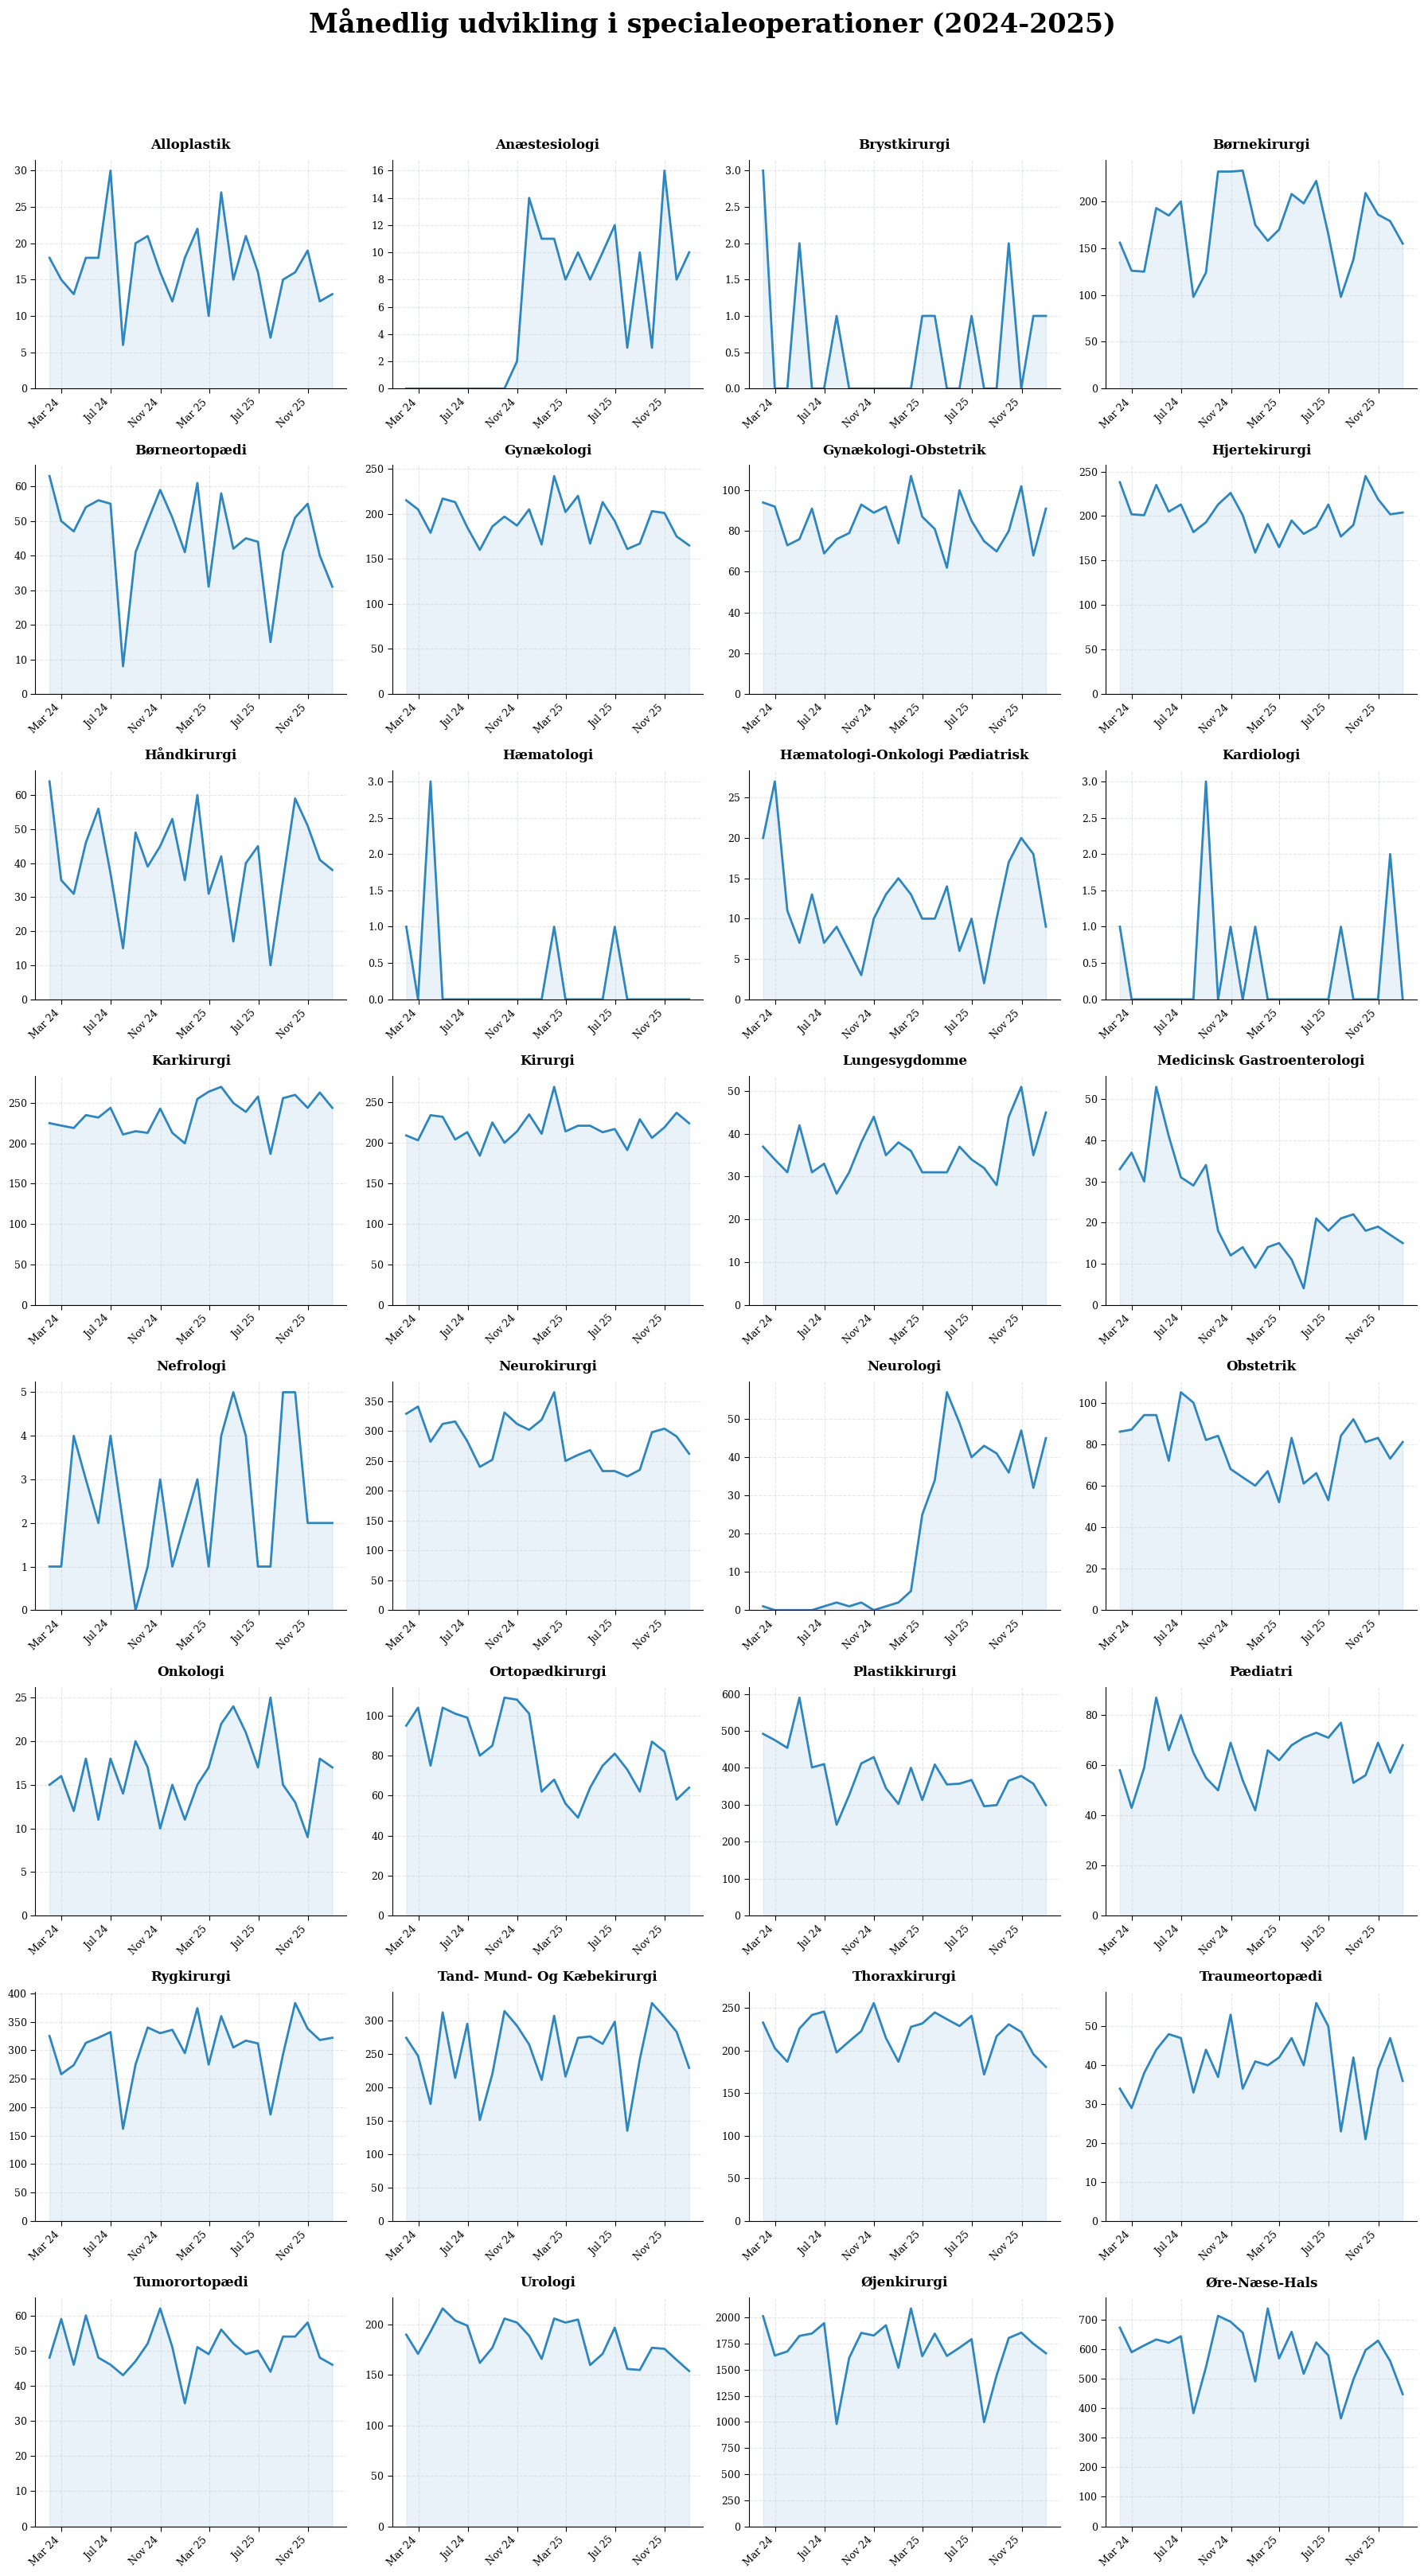

In [34]:
# 1. Datapræparation
# Vi sikrer os at datoen er korrekt formateret og sat som index
df_complete_wo['Dato'] = pd.to_datetime(df_complete_wo['Dato'].astype(str).str.split(',').str[0])
df_indexed = df_complete_wo.set_index('Dato')

# 2. Gruppering og pivotering (Månedlig opsummering)
# 'ME' står for Month End. Vi tæller antallet af rækker (operationer) pr. måned
monthly_pivot = df_indexed.groupby('Speciale').resample('ME').size().unstack(level=0).fillna(0)

# Liste over specialer til loopet
specialer = sorted(monthly_pivot.columns)

# 3. Layout indstillinger
ncols = 4  
nrows = math.ceil(len(specialer) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharex=False) # sharex=False for bedre kontrol
axes = axes.flatten()

fig.suptitle("Månedlig udvikling i specialeoperationer (2024-2025)", 
             fontsize=24, y=1.01, family='serif', weight='bold')

# 4. Plot loop
for i, speciale in enumerate(specialer):
    ax = axes[i]
    
    # Plot selve linjen og skyggen under den
    ax.plot(monthly_pivot.index, monthly_pivot[speciale], color='#2E86C1', linewidth=2, label=speciale)
    ax.fill_between(monthly_pivot.index, monthly_pivot[speciale], color='#2E86C1', alpha=0.1)
    
    # Titler og styling af det enkelte subplot
    ax.set_title(speciale.title(), family='serif', size=12, weight='bold', pad=10)
    ax.grid(True, linestyle='--', alpha=0.4, color='#BDC3C7')
    ax.set_ylim(bottom=0)
    
    # Formatering af X-aksen (Datoer)
    # Vi viser hver 4. måned for at undgå overlap (Feb, Jun, Okt osv.)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y')) 
    
    # Rotation af dato-labels for læsbarhed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', size=9, family='serif')
    plt.setp(ax.get_yticklabels(), size=9, family='serif')
    
    # Fjern top- og højre-ramme for et mere moderne udtryk
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4)

# 5. Oprydning: Fjern tomme felter hvis antallet af specialer ikke går op i 4
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Justering af layout så intet overlapper
# rect=[0, 0, 1, 0.98] sikrer at suptitle får plads i toppen
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_62693/2850433509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


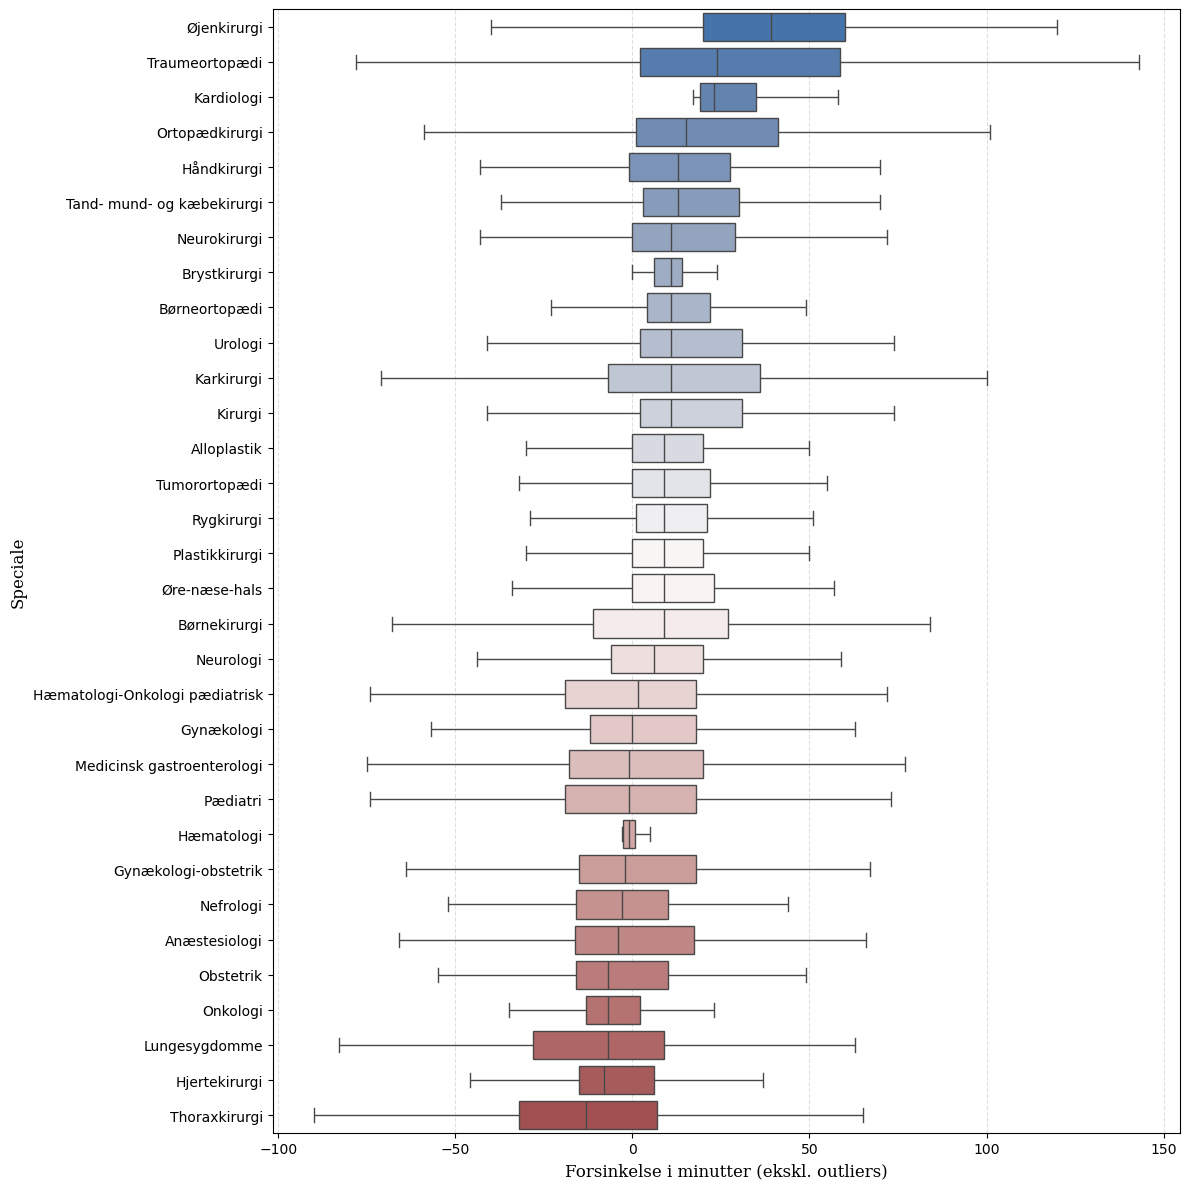

In [35]:
# 1. Beregn rækkefølgen baseret på median (så de mest forsinkede er øverst)
order = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().sort_values(ascending=False).index

# 2. Opsæt figuren
# Da du har 33 specialer, skal højden være stor (f.eks. 12) for at teksten ikke overlapper
fig, ax1 = plt.subplots(figsize=(12, 12))

# 3. Lav boxplottet
sns.boxplot(
    data=df_complete_wo, 
    x='Forsinkelse (minutter)', 
    y='Speciale', 
    order=order, 
    palette='vlag', 
    ax=ax1, 
    showfliers=False # Fjerner de vilde prikker så vi kan se kasserne tydeligt
)

# 4. Styling og titler
#ax1.set_title('Præcision: Fordeling af forsinkelser pr. speciale', fontsize=18, weight='bold', family='serif', pad=20)
ax1.set_xlabel('Forsinkelse i minutter (ekskl. outliers)', fontsize=12, family='serif')
ax1.set_ylabel('Speciale', fontsize=12, family='serif')

# Tilføj en rød lodret streg ved 0 (perfekt præcision)
#ax1.axvline(0, color='red', linestyle='--', alpha=0.6, label='Planlagt tid')

# Gør grid-linjerne tydelige på x-aksen for nemmere aflæsning
ax1.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [36]:
def count_outliers(group):
    Q1 = group['Forsinkelse (minutter)'].quantile(0.25)
    Q3 = group['Forsinkelse (minutter)'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    # Vi tæller kun dem over øvre grænse, da de er de mest kritiske forsinkelser
    return (group['Forsinkelse (minutter)'] > upper_bound).sum()

# Gruppér og tæl
outlier_counts = df_complete_wo.groupby('Speciale').apply(count_outliers).reset_index()
outlier_counts.columns = ['Speciale', 'Antal Outliers']

# Tilføj total antal operationer for at få en procentdel
total_counts = df_complete_wo['Speciale'].value_counts().reset_index()
total_counts.columns = ['Speciale', 'Total n']

outlier_summary = pd.merge(outlier_counts, total_counts, on='Speciale')
outlier_summary['Outlier pct'] = (outlier_summary['Antal Outliers'] / outlier_summary['Total n']) * 100

# Sortér efter flest outliers
outlier_summary = outlier_summary.sort_values(by='Antal Outliers', ascending=False)
print(outlier_summary.head(10))

                      Speciale  Antal Outliers  Total n  Outlier pct
31               Øre-næse-hals            1012    14010     7.223412
30                 Øjenkirurgi             898    40868     2.197318
24                  Rygkirurgi             737     7346    10.032671
22              Plastikkirurgi             559     9077     6.158422
13                     Kirurgi             513     5225     9.818182
7                Hjertekirurgi             505     4837    10.440356
29                     Urologi             415     4399     9.433962
25  Tand- mund- og kæbekirurgi             400     6125     6.530612
17                Neurokirurgi             390     6842     5.700088
12                  Karkirurgi             353     5662     6.234546


/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_62693/3484755023.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_counts = df_complete_wo.groupby('Speciale').apply(count_outliers).reset_index()


In [37]:
speciale1 = "Øjenkirurgi"

df1 = df_complete_wo[df_complete_wo['Speciale'] == speciale1]
df1['Akut case (J/N)'].value_counts()


Akut case (J/N)
Nej    37398
Ja      3470
Name: count, dtype: int64

In [38]:
df_complete_wo['Akut case (J/N)']

0         Nej
1         Nej
2         Nej
3         Nej
4         Nej
         ... 
133153    Nej
133154    Nej
133155    Nej
133156    Nej
133157    Nej
Name: Akut case (J/N), Length: 133158, dtype: object

In [39]:
for speciale in df_complete_wo['Speciale'].unique():
    df_speciale = df_complete_wo[df_complete_wo['Speciale'] == speciale]
    
    # Brug len() eller .shape[0] for at få selve antallet
    antal_ja = len(df_speciale[df_speciale['Akut case (J/N)'] == 'Ja'])
    antal_nej = len(df_speciale[df_speciale['Akut case (J/N)'] == 'Nej'])
    antal_total = len(df_speciale)
    
    print(f"Speciale: {speciale}")
    print(f"Ratio: {(antal_ja / antal_total)*100 if antal_total > 0 else 'N/A'}")
    print("-" * 20)

Speciale: Øre-næse-hals
Ratio: 12.84796573875803
--------------------
Speciale: Plastikkirurgi
Ratio: 9.760934229370937
--------------------
Speciale: Tand- mund- og kæbekirurgi
Ratio: 11.738775510204082
--------------------
Speciale: Øjenkirurgi
Ratio: 8.490750709601643
--------------------
Speciale: Børnekirurgi
Ratio: 16.854741896758703
--------------------
Speciale: Ortopædkirurgi
Ratio: 37.38414006179197
--------------------
Speciale: Børneortopædi
Ratio: 3.3057851239669422
--------------------
Speciale: Karkirurgi
Ratio: 34.72271282232427
--------------------
Speciale: Thoraxkirurgi
Ratio: 24.97147204260175
--------------------
Speciale: Hjertekirurgi
Ratio: 35.31114327062229
--------------------
Speciale: Urologi
Ratio: 25.414867015230737
--------------------
Speciale: Håndkirurgi
Ratio: 6.570841889117044
--------------------
Speciale: Kirurgi
Ratio: 45.014354066985646
--------------------
Speciale: Neurokirurgi
Ratio: 47.924583455130076
--------------------
Speciale: Pædiatri
R

In [40]:
# 1. Tæl J og N pr. speciale og beregn ratio
akut_tabel = df_complete_wo.groupby('Speciale')['Akut case (J/N)'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 2. Tilføj total antal (n) så man kan se volumen
akut_tabel['Total n'] = df_complete_wo.groupby('Speciale').size()

# 3. Sortér efter højeste ratio af akutte cases
akut_tabel = akut_tabel.sort_values(by='Ja', ascending=False)

# 4. Pæn navngivning af kolonner
akut_tabel.columns = ['Planlagt Ratio (%)', 'Akut Ratio (%)', 'Total Volumen (n)']
print(akut_tabel.head(10))

                            Planlagt Ratio (%)  Akut Ratio (%)  \
Speciale                                                         
Anæstesiologi                        96.323529        3.676471   
Neurologi                            88.362069       11.637931   
Obstetrik                            68.108974       31.891026   
Medicinsk gastroenterologi           67.910448       32.089552   
Kardiologi                           66.666667       33.333333   
Traumeortopædi                       53.989637       46.010363   
Gynækologi-obstetrik                 52.542373       47.457627   
Neurokirurgi                         47.924583       52.075417   
Nefrologi                            45.762712       54.237288   
Kirurgi                              45.014354       54.985646   

                            Total Volumen (n)  
Speciale                                       
Anæstesiologi                             136  
Neurologi                                 464  
Obstetrik      

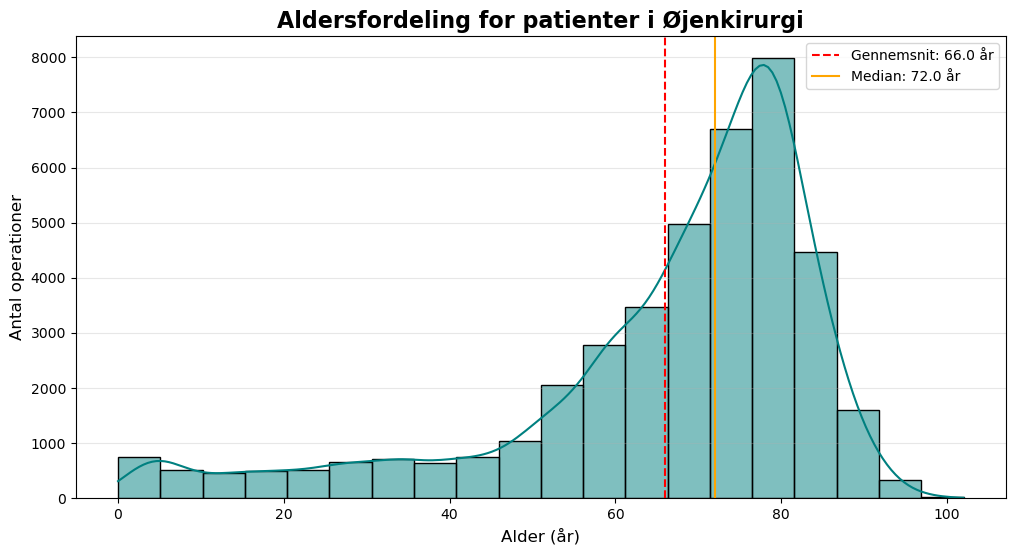

Statistik for Øjenkirurgi (n=40868):
Yngste patient: 0 år
Ældste patient: 102 år
Typisk alder (median): 72.0 år


In [41]:
# 1. Filtrér data så vi kun ser på Øjenkirurgi
df_øjen = df_complete_wo[df_complete_wo['Speciale'] == 'Øjenkirurgi']

# 2. Opsæt figuren
plt.figure(figsize=(12, 6))

# 3. Lav et histogram med en tæthedskurve (KDE)
sns.histplot(df_øjen['Patient Alder'], bins=20, kde=True, color='teal', edgecolor='black')

# 4. Tilføj statistiske linjer (Gennemsnit og Median)
mean_age = df_øjen['Patient Alder'].mean()
median_age = df_øjen['Patient Alder'].median()

plt.axvline(mean_age, color='red', linestyle='--', label=f'Gennemsnit: {mean_age:.1f} år')
plt.axvline(median_age, color='orange', linestyle='-', label=f'Median: {median_age:.1f} år')

# 5. Styling
plt.title('Aldersfordeling for patienter i Øjenkirurgi', fontsize=16, weight='bold')
plt.xlabel('Alder (år)', fontsize=12)
plt.ylabel('Antal operationer', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Print hurtig statistik
print(f"Statistik for Øjenkirurgi (n={len(df_øjen)}):")
print(f"Yngste patient: {df_øjen['Patient Alder'].min()} år")
print(f"Ældste patient: {df_øjen['Patient Alder'].max()} år")
print(f"Typisk alder (median): {median_age} år")

/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_62693/3451504359.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


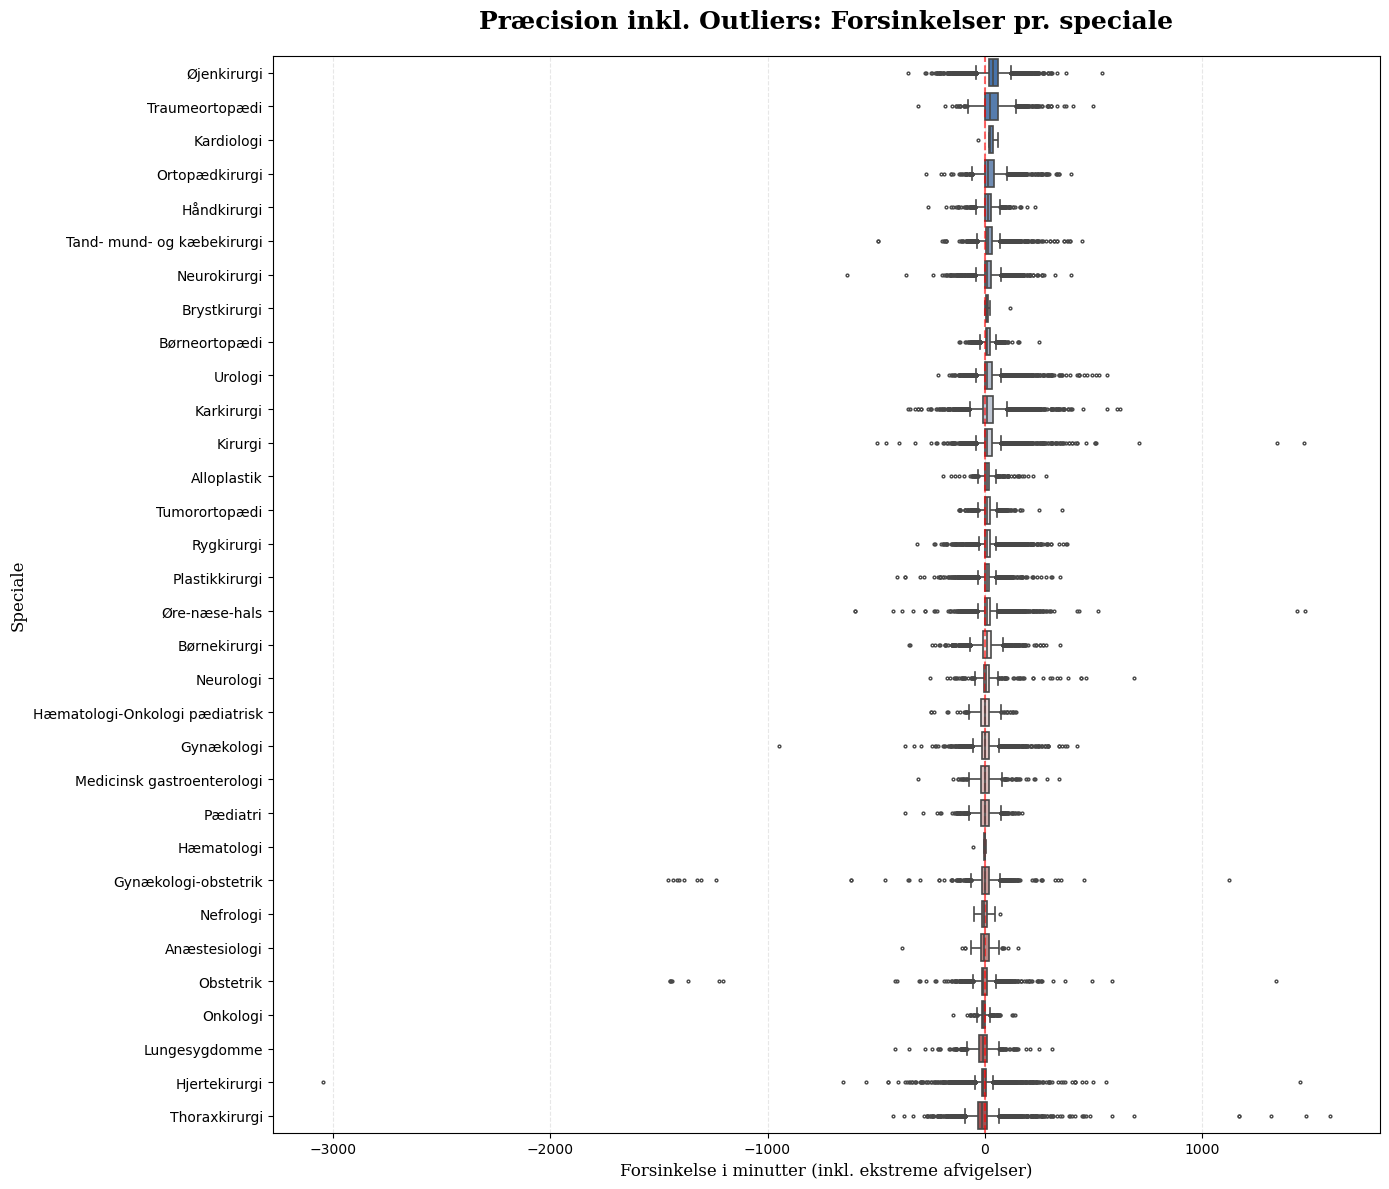

In [42]:
# 1. Beregn rækkefølgen baseret på median
order = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().sort_values(ascending=False).index

# 2. Opsæt figuren (vi gør den lidt bredere for at give plads til outliers)
fig, ax1 = plt.subplots(figsize=(14, 12))

# 3. Lav boxplottet MED outliers
sns.boxplot(
    data=df_complete_wo, 
    x='Forsinkelse (minutter)', 
    y='Speciale', 
    order=order, 
    palette='vlag', 
    ax=ax1, 
    showfliers=True,  # Her beholder vi outliers
    fliersize=2,      # Mindre prikker for bedre overblik
    linewidth=1.2,
    whis=1.5          # Standard definition af outliers
)

# 4. Styling og titler
ax1.set_title('Præcision inkl. Outliers: Forsinkelser pr. speciale', fontsize=18, weight='bold', family='serif', pad=20)
ax1.set_xlabel('Forsinkelse i minutter (inkl. ekstreme afvigelser)', fontsize=12, family='serif')
ax1.set_ylabel('Speciale', fontsize=12, family='serif')

# Tilføj en rød lodret streg ved 0
ax1.axvline(0, color='red', linestyle='--', alpha=0.6, label='Planlagt tid')

# Sæt et fornuftigt limit på x-aksen hvis der er fejl-indtastninger (f.eks. 1000 min)
# ax1.set_xlim(-60, 600) 

ax1.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# 1. Forberedelse af data
# Vi filtrerer ekstreme fejl-indtastninger fra (f.eks. hvis forsinkelse er 0 eller negativ, afhængig af data)
# Vi fokuserer på de 10 specialer med flest forsinkelser for at gøre plottet overskueligt
top_specialer = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().nlargest(33).index
df_plot = df_complete_wo[df_complete_wo['Speciale'].isin(top_specialer)]


# --- PLOT 1: Fordeling af forsinkelser pr. speciale (Boxplot) ---
sns.boxplot(data=df_plot, x='Forsinkelse (minutter)', y='Speciale', 
            palette='vlag', ax=ax1, showfliers=False) # showfliers=False fjerner ekstreme outliers for bedre overblik
ax1.set_title('Præcision: Fordeling af forsinkelser (Top 10 specialer efter median)', fontsize=16, weight='bold', family='serif')
ax1.set_xlabel('Forsinkelse i minutter (Ekskl. ekstreme outliers)', fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.6)

/var/folders/p9/p8xtbn1s27v69xbxcl4dpgtc0000gn/T/ipykernel_62693/2515723723.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Forsinkelse (minutter)', y='Speciale',


In [44]:
# --- PLOT 2: Hvad er årsagen til forsinkelserne? ---
# Vi tæller de hyppigste årsager
causes = df_complete_wo['Forsinkelsesårsag'].value_counts().nlargest(10)
sns.barplot(x=causes.values, y=causes.index, palette='viridis', ax=ax2)
ax2.set_title('De 10 hyppigste årsager til forsinkelse', fontsize=16, weight='bold', family='serif')
ax2.set_xlabel('Antal hændelser', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Beregn en hurtig "Præcisions-score"
total_cases = len(df_complete_wo)
on_time_cases = len(df_complete_wo[df_complete_wo['Forsinkelse (minutter)'] <= 30]) # 30 min buffer
precision_pct = (on_time_cases / total_cases) * 100

print(f"Samlet præcision: {precision_pct:.1f}% af alle operationer starter inden for 30 minutter af planlagt tid.")

NameError: name 'ax2' is not defined

In [ ]:
# Beregn median forsinkelse pr. speciale
median_delay = df_complete_wo.groupby('Speciale')['Forsinkelse (minutter)'].median().reset_index()

# Beregn også antal operationer (n) for at give tabellen kontekst
counts = df_complete_wo['Speciale'].value_counts().reset_index()
counts.columns = ['Speciale', 'Antal operationer (n)']

# Merge de to ting sammen
result_table = pd.merge(median_delay, counts, on='Speciale')

# Sortér så de mest forsinkede står øverst
result_table = result_table.sort_values(by='Forsinkelse (minutter)', ascending=False).reset_index(drop=True)

# Omdøb kolonnen for overskuelighed
result_table.columns = ['Speciale', 'Median Forsinkelse (min)', 'Volumen (n)']

# Vis tabellen
print(result_table)

                          Speciale  Median Forsinkelse (min)  Volumen (n)
0                      Øjenkirurgi                      39.0        40868
1                   Traumeortopædi                      24.0          965
2                       Kardiologi                      23.0            9
3                   Ortopædkirurgi                      15.0         1942
4                      Håndkirurgi                      13.0          974
5       Tand- mund- og kæbekirurgi                      13.0         6125
6                     Neurokirurgi                      11.0         6842
7                     Brystkirurgi                      11.0           13
8                    Børneortopædi                      11.0         1089
9                          Urologi                      11.0         4399
10                      Karkirurgi                      11.0         5662
11                         Kirurgi                      11.0         5225
12                     Alloplastik    

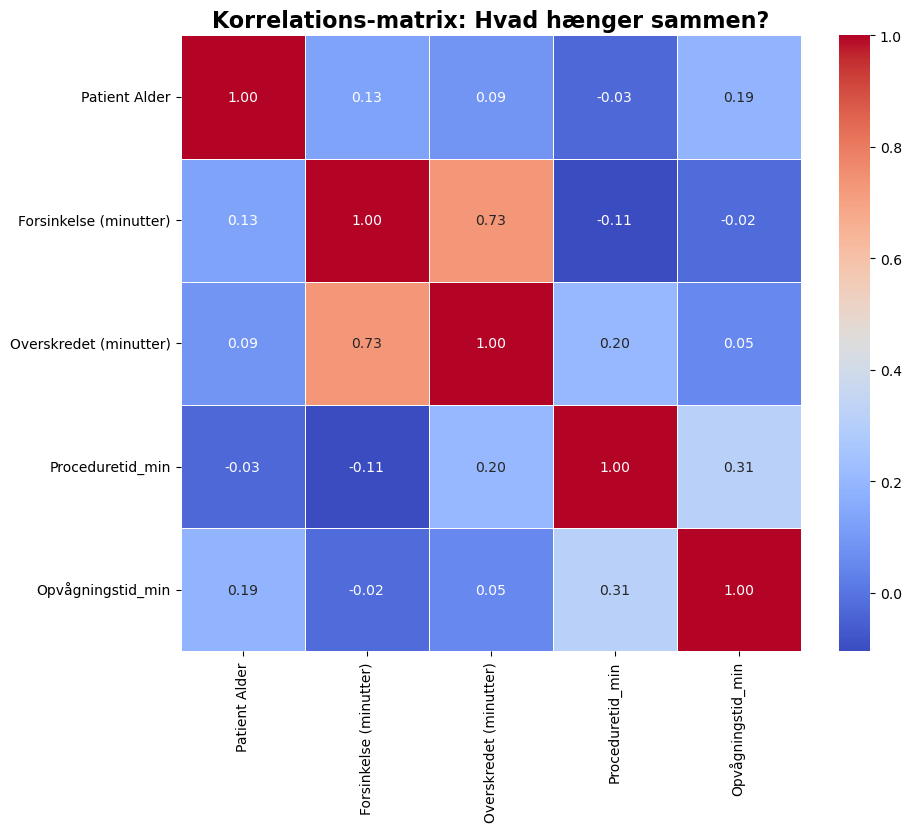

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vi skal først beregne varighederne i minutter for at kunne korrelere dem
df_complete_wo['Opvågningstid_min'] = (df_complete_wo['Klar til udskrivelse efter opvågning'] - df_complete_wo['I opvågning']).dt.total_seconds() / 60
df_complete_wo['Proceduretid_min'] = (df_complete_wo['Procedure slut'] - df_complete_wo['Procedure start']).dt.total_seconds() / 60

# Vælg de numeriske kolonner vi vil tjekke
cols_to_corr = ['Patient Alder', 'Forsinkelse (minutter)', 'Overskredet (minutter)', 'Proceduretid_min', 'Opvågningstid_min']
corr_matrix = df_complete_wo[cols_to_corr].corr()

# Lav Heatmappet
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelations-matrix: Hvad hænger sammen?', fontsize=16, weight='bold')
plt.show()